# Notebook 3 — Ensemble Classification & Decision Tree Regression

This notebook covers two advanced modelling tasks for the **Loan Approval Dataset**:  
1. **Part A** — Build an **Ensemble (Voting) Classifier** combining Logistic Regression and KNN, evaluated with recall as the priority metric.  
2. **Part B** — Build **Decision Tree Regression** models to predict the maximum allowed loan amount for approved applications.  
3. **Part C** — Predict loan amount for a **new client** using both Decision Tree models.  

All data is loaded from Notebook 1 (`loan_data_preprocessing.ipynb`).

---
## Part A — Ensemble Classification

We build a **Voting Classifier** that combines Logistic Regression and K-Nearest Neighbours using soft voting.  
Soft voting averages the predicted probabilities from each base model, which typically yields better calibrated predictions than hard voting.

### Step 1 — Load Preprocessed Data

We use the `%run` magic command to execute Notebook 1 and import all preprocessed variables into this notebook's namespace.

=== First 5 Rows of the Dataset ===
=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  str    
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  str    
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  str    
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7)

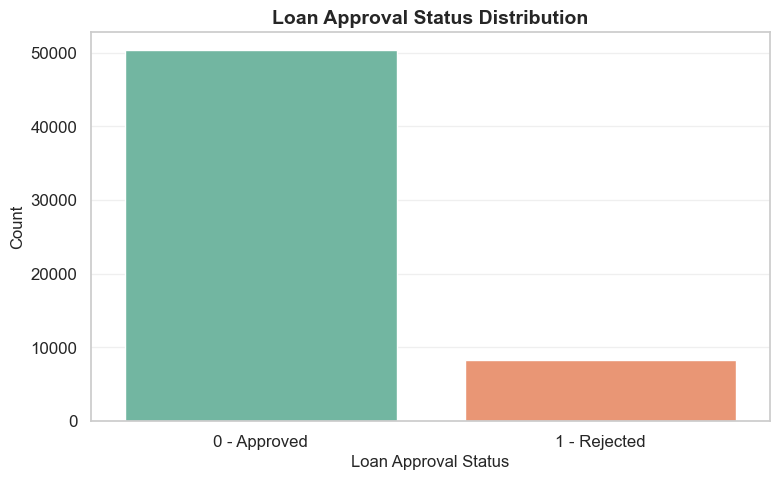

Total Applications: 58645
Approved: 50295 (85.76%)
Rejected: 8350 (14.24%)
=== Regression Dataset Created (Approved Loans Only) ===
X_regression shape: (50295, 10)
y_regression shape: (50295,)

=== Regression Target Statistics ===
count    5.029500e+04
mean     8.133543e+04
std      5.919723e+04
min     -2.426900e+06
25%      4.909150e+04
50%      6.942700e+04
75%      9.898900e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64
=== Feature Scaling Complete ===
X_classification_scaled shape: (58645, 11)
X_classification_scaled type:  <class 'pandas.DataFrame'>

X_regression_scaled shape:    (50295, 10)
X_regression_scaled type:     <class 'pandas.DataFrame'>
=== Final Variable Types ===
X_classification_scaled: <class 'pandas.DataFrame'>
y_classification dtype:  int64
X_regression_scaled:     <class 'pandas.DataFrame'>
y_regression dtype:      int64

PREPROCESSING COMPLETE - FINAL SUMMARY

=== Classification Dataset ===
X_classification shape:        (58645, 11)
X_classifi

In [1]:
# Run the preprocessing notebook to load all prepared variables
%run loan_data_preprocessing.ipynb

### Step 2 — Safety Checks

We verify that all required variables from Notebook 1 are available before proceeding.

In [2]:
# Safety check: ensure X_classification_scaled exists from Notebook 1
if 'X_classification_scaled' not in dir():
    raise RuntimeError('X_classification_scaled not found. Please run Notebook 1 first.')

# Safety check: ensure y_classification exists from Notebook 1
if 'y_classification' not in dir():
    raise RuntimeError('y_classification not found. Please run Notebook 1 first.')

# Safety check: ensure X_regression_scaled exists from Notebook 1
if 'X_regression_scaled' not in dir():
    raise RuntimeError('X_regression_scaled not found. Please run Notebook 1 first.')

# Safety check: ensure y_regression exists from Notebook 1
if 'y_regression' not in dir():
    raise RuntimeError('y_regression not found. Please run Notebook 1 first.')

# Print confirmation that all required variables are loaded
print('=== All Required Variables Loaded Successfully ===')

# Print the shape of the classification features
print(f'X_classification_scaled shape: {X_classification_scaled.shape}')

# Print the shape of the classification target
print(f'y_classification shape:        {y_classification.shape}')

# Print the shape of the regression features
print(f'X_regression_scaled shape:     {X_regression_scaled.shape}')

# Print the shape of the regression target
print(f'y_regression shape:            {y_regression.shape}')

=== All Required Variables Loaded Successfully ===
X_classification_scaled shape: (58645, 11)
y_classification shape:        (58645,)
X_regression_scaled shape:     (50295, 10)
y_regression shape:            (50295,)


### Step 3 — Train-Test Split (Classification)

We split the classification data into 80% training and 20% testing sets using stratified sampling to preserve the class distribution.  
A fixed `random_state=42` ensures reproducibility.

In [3]:
# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Split the classification data: 80% training, 20% testing, stratified by target
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification_scaled, y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

# Print a header for the split summary
print('=== Classification Train-Test Split Complete ===')

# Print the shape of the training features
print(f'X_train_cls shape: {X_train_cls.shape}')

# Print the shape of the testing features
print(f'X_test_cls shape:  {X_test_cls.shape}')

# Print the shape of the training target
print(f'y_train_cls shape: {y_train_cls.shape}')

# Print the shape of the testing target
print(f'y_test_cls shape:  {y_test_cls.shape}')

# Print the class distribution in the training set
print('\n=== Class Distribution (Training Set) ===')

# Display the value counts for the training target
print(y_train_cls.value_counts().sort_index())

# Print the class distribution in the test set
print('\n=== Class Distribution (Test Set) ===')

# Display the value counts for the testing target
print(y_test_cls.value_counts().sort_index())

=== Classification Train-Test Split Complete ===
X_train_cls shape: (46916, 11)
X_test_cls shape:  (11729, 11)
y_train_cls shape: (46916,)
y_test_cls shape:  (11729,)

=== Class Distribution (Training Set) ===
loan_approval_status
0    40236
1     6680
Name: count, dtype: int64

=== Class Distribution (Test Set) ===
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64


### Step 4 — Build Base Models

We create the two base classifiers that will form our ensemble:  
1. **Logistic Regression** — a linear model with `max_iter=1000`  
2. **K-Nearest Neighbours (KNN)** — with `n_neighbors=5`

In [4]:
# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Import K-Nearest Neighbours classifier
from sklearn.neighbors import KNeighborsClassifier

# Create the Logistic Regression base model with max_iter=1000
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Create the KNN base model with n_neighbors=5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Print confirmation of base models created
print('=== Base Models Created ===')

# Print the Logistic Regression model configuration
print(f'  1. Logistic Regression: {lr_model}')

# Print the KNN model configuration
print(f'  2. KNN:                 {knn_model}')

=== Base Models Created ===
  1. Logistic Regression: LogisticRegression(max_iter=1000, random_state=42)
  2. KNN:                 KNeighborsClassifier()


### Step 5 — Build Voting Classifier (Soft Voting)

We combine the two base models into a **VotingClassifier** using soft voting.  
Soft voting averages the predicted class probabilities from each estimator to make the final prediction.

In [5]:
# Import the VotingClassifier from sklearn
from sklearn.ensemble import VotingClassifier

# Create the ensemble model combining LR and KNN with soft voting
ensemble_model = VotingClassifier(
    estimators=[('lr', lr_model), ('knn', knn_model)],
    voting='soft'
)

# Print confirmation of ensemble model creation
print('=== Voting Classifier Created ===')

# Print the ensemble model configuration
print(f'Voting method: soft')

# Print the base estimators
print(f'Base estimators: Logistic Regression, KNN')

=== Voting Classifier Created ===
Voting method: soft
Base estimators: Logistic Regression, KNN


### Step 6 — Train the Ensemble Model

We fit the Voting Classifier on the training data.

In [6]:
# Train the ensemble model on the training data
ensemble_model.fit(X_train_cls, y_train_cls)

# Print confirmation that training is complete
print('=== Ensemble Model Training Complete ===')

=== Ensemble Model Training Complete ===


### Step 7 — Evaluate the Ensemble Model

We evaluate the ensemble classifier using multiple metrics:  
- **Confusion Matrix** — shows true/false positives and negatives  
- **Classification Report** — precision, recall, and F1-score per class  
- **Individual Metrics** — accuracy, recall, precision, F1-score, and AUC-ROC  

**Recall (Reject class)** is our priority metric because failing to identify a rejected loan application is more costly.

In [7]:
# Import required evaluation metrics
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Generate predicted class labels on the test set
y_pred_ensemble = ensemble_model.predict(X_test_cls)

# Generate predicted probability scores for the positive class
y_score_ensemble = ensemble_model.predict_proba(X_test_cls)[:, 1]

# Compute accuracy
acc_ensemble = accuracy_score(y_test_cls, y_pred_ensemble)

# Compute recall for the reject class (pos_label=1)
rec_ensemble = recall_score(y_test_cls, y_pred_ensemble, pos_label=1)

# Compute precision for the reject class (pos_label=1, zero_division=0)
prec_ensemble = precision_score(y_test_cls, y_pred_ensemble, pos_label=1, zero_division=0)

# Compute F1-score for the reject class
f1_ensemble = f1_score(y_test_cls, y_pred_ensemble, pos_label=1)

# Compute the AUC-ROC score using probability scores
auc_ensemble = roc_auc_score(y_test_cls, y_score_ensemble)

# Print the evaluation header
print('=' * 60)
print('ENSEMBLE MODEL EVALUATION (Voting Classifier)')
print('=' * 60)

# Print the confusion matrix
print('\n--- Confusion Matrix ---')
print(confusion_matrix(y_test_cls, y_pred_ensemble))

# Print the full classification report
print('\n--- Classification Report ---')
print(classification_report(y_test_cls, y_pred_ensemble, zero_division=0))

# Print the metric summary
print('--- Metric Summary ---')

# Print accuracy
print(f'  Accuracy:              {acc_ensemble:.4f}')

# Print recall for the reject class
print(f'  Recall (Reject class): {rec_ensemble:.4f}')

# Print precision
print(f'  Precision:             {prec_ensemble:.4f}')

# Print F1-score
print(f'  F1-Score:              {f1_ensemble:.4f}')

# Print AUC-ROC
print(f'  AUC-ROC:               {auc_ensemble:.4f}')

# Print closing separator
print('=' * 60)

ENSEMBLE MODEL EVALUATION (Voting Classifier)

--- Confusion Matrix ---
[[10023    36]
 [   35  1635]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10059
           1       0.98      0.98      0.98      1670

    accuracy                           0.99     11729
   macro avg       0.99      0.99      0.99     11729
weighted avg       0.99      0.99      0.99     11729

--- Metric Summary ---
  Accuracy:              0.9939
  Recall (Reject class): 0.9790
  Precision:             0.9785
  F1-Score:              0.9787
  AUC-ROC:               0.9996


### Step 8 — ROC Curve for Ensemble Model

We plot the ROC curve for the Voting Classifier, showing the trade-off between True Positive Rate and False Positive Rate.

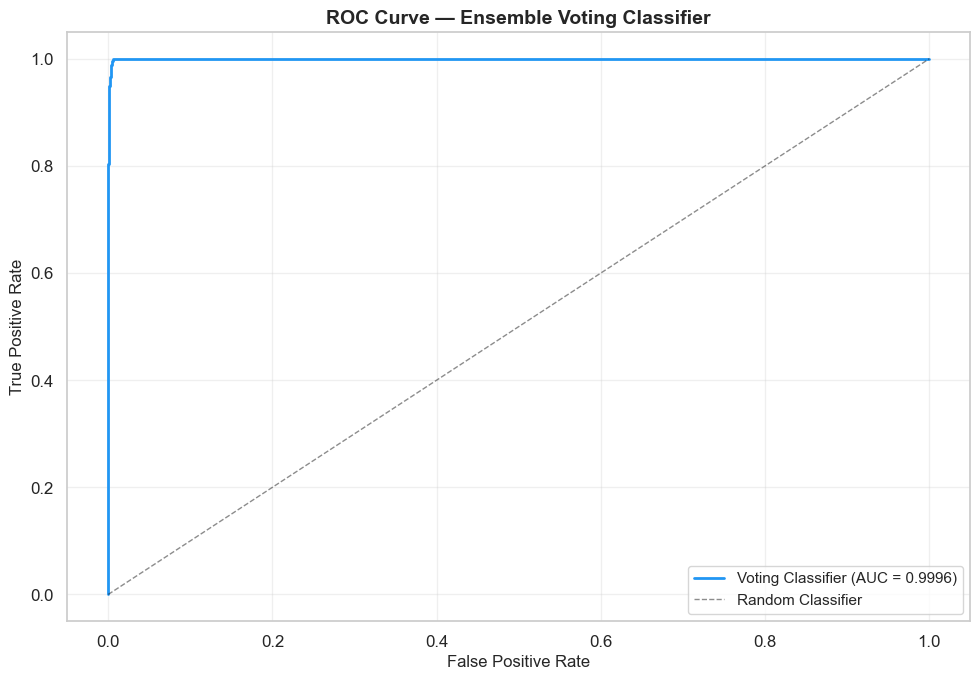

In [8]:
# Import the ROC curve function
from sklearn.metrics import roc_curve

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Compute FPR, TPR, and thresholds for the ensemble model
fpr_ens, tpr_ens, _ = roc_curve(y_test_cls, y_score_ensemble)

# Create a new figure with specified dimensions
plt.figure(figsize=(10, 7))

# Plot the ROC curve for the ensemble model with AUC in the label
plt.plot(fpr_ens, tpr_ens, color='#2196F3', linewidth=2,
         label=f'Voting Classifier (AUC = {auc_ensemble:.4f})')

# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

# Set the plot title
plt.title('ROC Curve — Ensemble Voting Classifier', fontsize=14, fontweight='bold')

# Set the x-axis label
plt.xlabel('False Positive Rate', fontsize=12)

# Set the y-axis label
plt.ylabel('True Positive Rate', fontsize=12)

# Add the legend to the lower-right corner
plt.legend(loc='lower right', fontsize=11)

# Add gridlines for readability
plt.grid(alpha=0.3)

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the plot
plt.show()

### Step 9 — Ensemble Classification Summary

We print a clean summary of all ensemble classification metrics.

In [9]:
# Print a final summary of all ensemble metrics
print('\n' + '=' * 60)
print('ENSEMBLE CLASSIFICATION — FINAL SUMMARY')
print('=' * 60)

# Print model type
print(f'\nModel:                   Voting Classifier (LR + KNN, soft voting)')

# Print accuracy
print(f'Accuracy:                {acc_ensemble:.4f}')

# Print recall for the reject class
print(f'Recall (Reject class):   {rec_ensemble:.4f}')

# Print precision
print(f'Precision:               {prec_ensemble:.4f}')

# Print F1-score
print(f'F1-Score:                {f1_ensemble:.4f}')

# Print AUC-ROC
print(f'AUC-ROC:                 {auc_ensemble:.4f}')

# Print closing separator
print('=' * 60)


ENSEMBLE CLASSIFICATION — FINAL SUMMARY

Model:                   Voting Classifier (LR + KNN, soft voting)
Accuracy:                0.9939
Recall (Reject class):   0.9790
Precision:               0.9785
F1-Score:                0.9787
AUC-ROC:                 0.9996


---
## Part B — Decision Tree Regression

We build two Decision Tree Regression models to predict `max_allowed_loan` for approved applications:  
- **DT1**: Default parameters (no depth restriction) — may overfit  
- **DT2**: Restricted depth (`max_depth=4`) — designed to generalise better  

We compare their performance using MSE, MAE, and R² metrics.

### Step 10 — Load and Inspect Regression Data

We use the regression variables (`X_regression_scaled`, `y_regression`) from Notebook 1 and inspect their shapes and summary statistics.

In [10]:
# Print a header for the regression data summary
print('=== Regression Data Summary ===')

# Print the shape of the regression features
print(f'X_regression_scaled shape: {X_regression_scaled.shape}')

# Print the shape of the regression target
print(f'y_regression shape:        {y_regression.shape}')

# Print descriptive statistics of the regression target
print('\n=== y_regression Descriptive Statistics ===')

# Display summary statistics for the target variable
print(y_regression.describe())

=== Regression Data Summary ===
X_regression_scaled shape: (50295, 10)
y_regression shape:        (50295,)

=== y_regression Descriptive Statistics ===
count    5.029500e+04
mean     8.133543e+04
std      5.919723e+04
min     -2.426900e+06
25%      4.909150e+04
50%      6.942700e+04
75%      9.898900e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


### Step 11 — Train-Test Split (Regression)

We split the regression data into 80% training and 20% testing sets.  
Note: Stratification is **not used** for regression targets.

In [11]:
# Split the regression data: 80% training, 20% testing (no stratify for regression)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression_scaled, y_regression,
    test_size=0.2,
    random_state=42
)

# Print a header for the split summary
print('=== Regression Train-Test Split Complete ===')

# Print the shape of the training features
print(f'X_train_reg shape: {X_train_reg.shape}')

# Print the shape of the testing features
print(f'X_test_reg shape:  {X_test_reg.shape}')

# Print the shape of the training target
print(f'y_train_reg shape: {y_train_reg.shape}')

# Print the shape of the testing target
print(f'y_test_reg shape:  {y_test_reg.shape}')

=== Regression Train-Test Split Complete ===
X_train_reg shape: (40236, 10)
X_test_reg shape:  (10059, 10)
y_train_reg shape: (40236,)
y_test_reg shape:  (10059,)


### Step 12 — Build Two Decision Tree Regressors

We create two models:  
- **DT1**: Default `DecisionTreeRegressor` — no depth limit  
- **DT2**: `DecisionTreeRegressor` with `max_depth=4` — constrained for better generalisation

In [12]:
# Import the DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor

# Create DT1: Decision Tree Regressor with default parameters
dt1_model = DecisionTreeRegressor(random_state=42)

# Create DT2: Decision Tree Regressor with max_depth=4
dt2_model = DecisionTreeRegressor(max_depth=4, random_state=42)

# Print confirmation of models created
print('=== Decision Tree Regressors Created ===')

# Print DT1 configuration
print(f'  DT1: DecisionTreeRegressor (default, max_depth={dt1_model.max_depth})')

# Print DT2 configuration
print(f'  DT2: DecisionTreeRegressor (max_depth={dt2_model.max_depth})')

=== Decision Tree Regressors Created ===
  DT1: DecisionTreeRegressor (default, max_depth=None)
  DT2: DecisionTreeRegressor (max_depth=4)


### Step 13 — Train Both Decision Tree Models

We fit both DT1 and DT2 on the training data.

In [13]:
# Train DT1 on the training data
dt1_model.fit(X_train_reg, y_train_reg)

# Print confirmation for DT1
print('DT1 training complete.')

# Train DT2 on the training data
dt2_model.fit(X_train_reg, y_train_reg)

# Print confirmation for DT2
print('DT2 training complete.')

# Print overall confirmation
print('\n=== Both Decision Tree Models Trained Successfully ===')

DT1 training complete.
DT2 training complete.

=== Both Decision Tree Models Trained Successfully ===


### Step 14 — Generate Predictions

We use both trained models to predict `max_allowed_loan` on the test set.

In [14]:
# Generate predictions using DT1
y_pred_dt1 = dt1_model.predict(X_test_reg)

# Generate predictions using DT2
y_pred_dt2 = dt2_model.predict(X_test_reg)

# Print confirmation of predictions
print('=== Predictions Generated ===')

# Print the number of predictions from DT1
print(f'DT1 predictions: {len(y_pred_dt1)} samples')

# Print the number of predictions from DT2
print(f'DT2 predictions: {len(y_pred_dt2)} samples')

=== Predictions Generated ===
DT1 predictions: 10059 samples
DT2 predictions: 10059 samples


### Step 15 — Evaluate Both Models

We compute MSE, MAE, and R² for both Decision Tree models and print the results clearly.

In [15]:
# Import regression evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute MSE for DT1
mse_dt1 = mean_squared_error(y_test_reg, y_pred_dt1)

# Compute MAE for DT1
mae_dt1 = mean_absolute_error(y_test_reg, y_pred_dt1)

# Compute R² for DT1
r2_dt1 = r2_score(y_test_reg, y_pred_dt1)

# Compute MSE for DT2
mse_dt2 = mean_squared_error(y_test_reg, y_pred_dt2)

# Compute MAE for DT2
mae_dt2 = mean_absolute_error(y_test_reg, y_pred_dt2)

# Compute R² for DT2
r2_dt2 = r2_score(y_test_reg, y_pred_dt2)

# Print evaluation header for DT1
print('=' * 60)
print('MODEL: DT1 — Decision Tree (Default)')
print('=' * 60)

# Print MSE for DT1
print(f'  MSE:  {mse_dt1:,.2f}')

# Print MAE for DT1
print(f'  MAE:  {mae_dt1:,.2f}')

# Print R² for DT1
print(f'  R²:   {r2_dt1:.4f}')

# Print evaluation header for DT2
print('\n' + '=' * 60)
print('MODEL: DT2 — Decision Tree (max_depth=4)')
print('=' * 60)

# Print MSE for DT2
print(f'  MSE:  {mse_dt2:,.2f}')

# Print MAE for DT2
print(f'  MAE:  {mae_dt2:,.2f}')

# Print R² for DT2
print(f'  R²:   {r2_dt2:.4f}')

MODEL: DT1 — Decision Tree (Default)
  MSE:  69,738,517.91
  MAE:  1,244.92
  R²:   0.9765

MODEL: DT2 — Decision Tree (max_depth=4)
  MSE:  404,642,149.18
  MAE:  11,935.26
  R²:   0.8639


### Step 16 — Model Comparison Table

We display a comparison table showing DT1 vs DT2 across all regression metrics.

In [16]:
# Import pandas for creating the comparison table
import pandas as pd

# Create a comparison DataFrame with metrics for both models
comparison_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'R²'],
    'DT1 (Default)': [f'{mse_dt1:,.2f}', f'{mae_dt1:,.2f}', f'{r2_dt1:.4f}'],
    'DT2 (max_depth=4)': [f'{mse_dt2:,.2f}', f'{mae_dt2:,.2f}', f'{r2_dt2:.4f}']
})

# Print the comparison table header
print('=== Decision Tree Regression — Model Comparison ===')

# Display the comparison DataFrame
print(comparison_df.to_string(index=False))

=== Decision Tree Regression — Model Comparison ===
Metric DT1 (Default) DT2 (max_depth=4)
   MSE 69,738,517.91    404,642,149.18
   MAE      1,244.92         11,935.26
    R²        0.9765            0.8639


### Step 17 — Visualise Decision Trees

We visualise both decision trees using `sklearn.tree.plot_tree`.  
- **DT1** is shown with `max_depth=3` for readability  
- **DT2** is shown in full since it has `max_depth=4`  

Both trees use `filled=True`, `rounded=True`, `impurity=True`, and `proportion=True`.

In [17]:
# Import the plot_tree function for tree visualisation
from sklearn.tree import plot_tree

# Extract feature names from the regression dataset
feature_names = list(X_regression_scaled.columns)

# Print the feature names for verification
print(f'Feature names: {feature_names}')

# Print the number of features
print(f'Number of features: {len(feature_names)}')

Feature names: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Number of features: 10


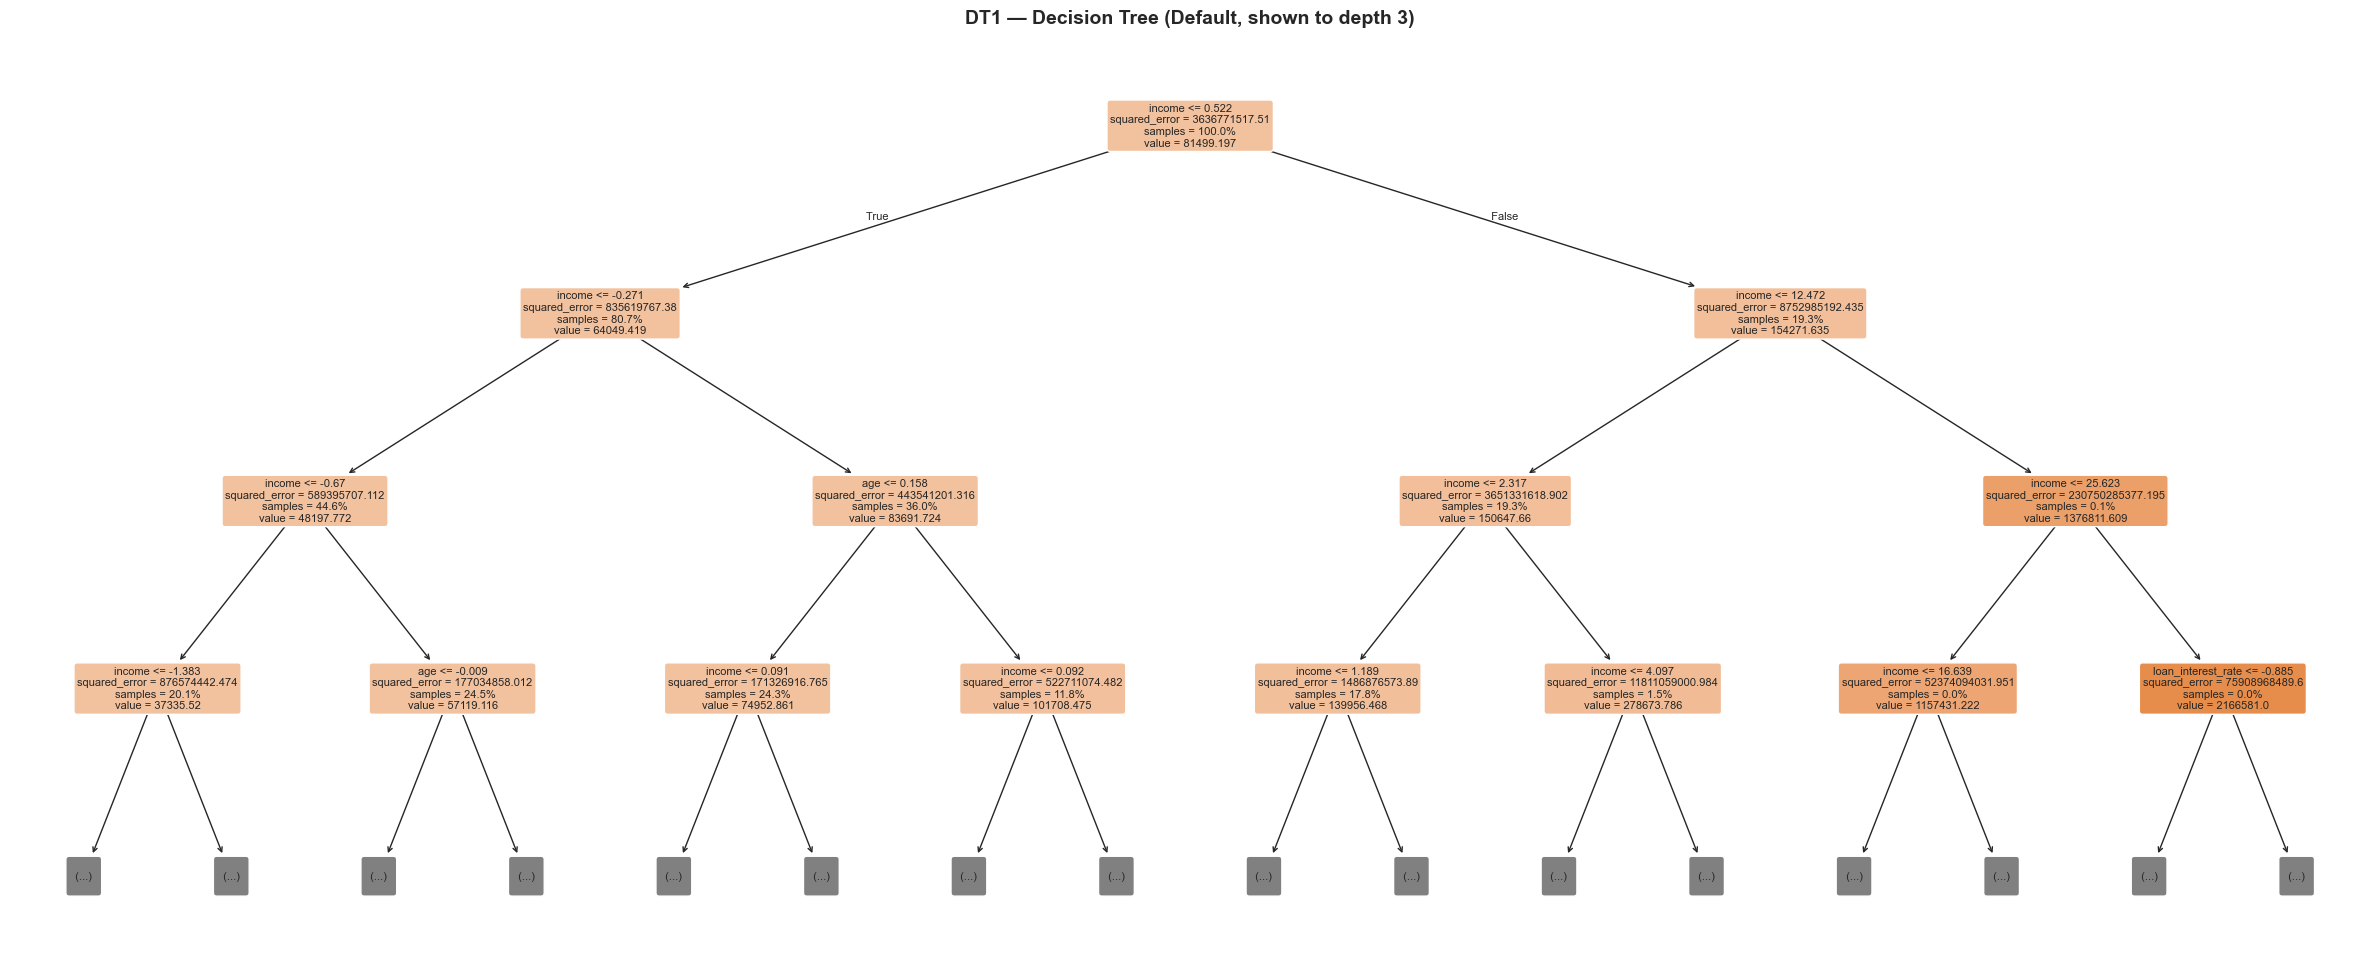

In [18]:
# Create a figure for DT1 visualisation
plt.figure(figsize=(24, 10))

# Plot DT1 with max_depth=3 for readability
plot_tree(
    dt1_model,
    max_depth=3,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=8
)

# Set the title for DT1
plt.title('DT1 — Decision Tree (Default, shown to depth 3)', fontsize=14, fontweight='bold')

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the plot
plt.show()

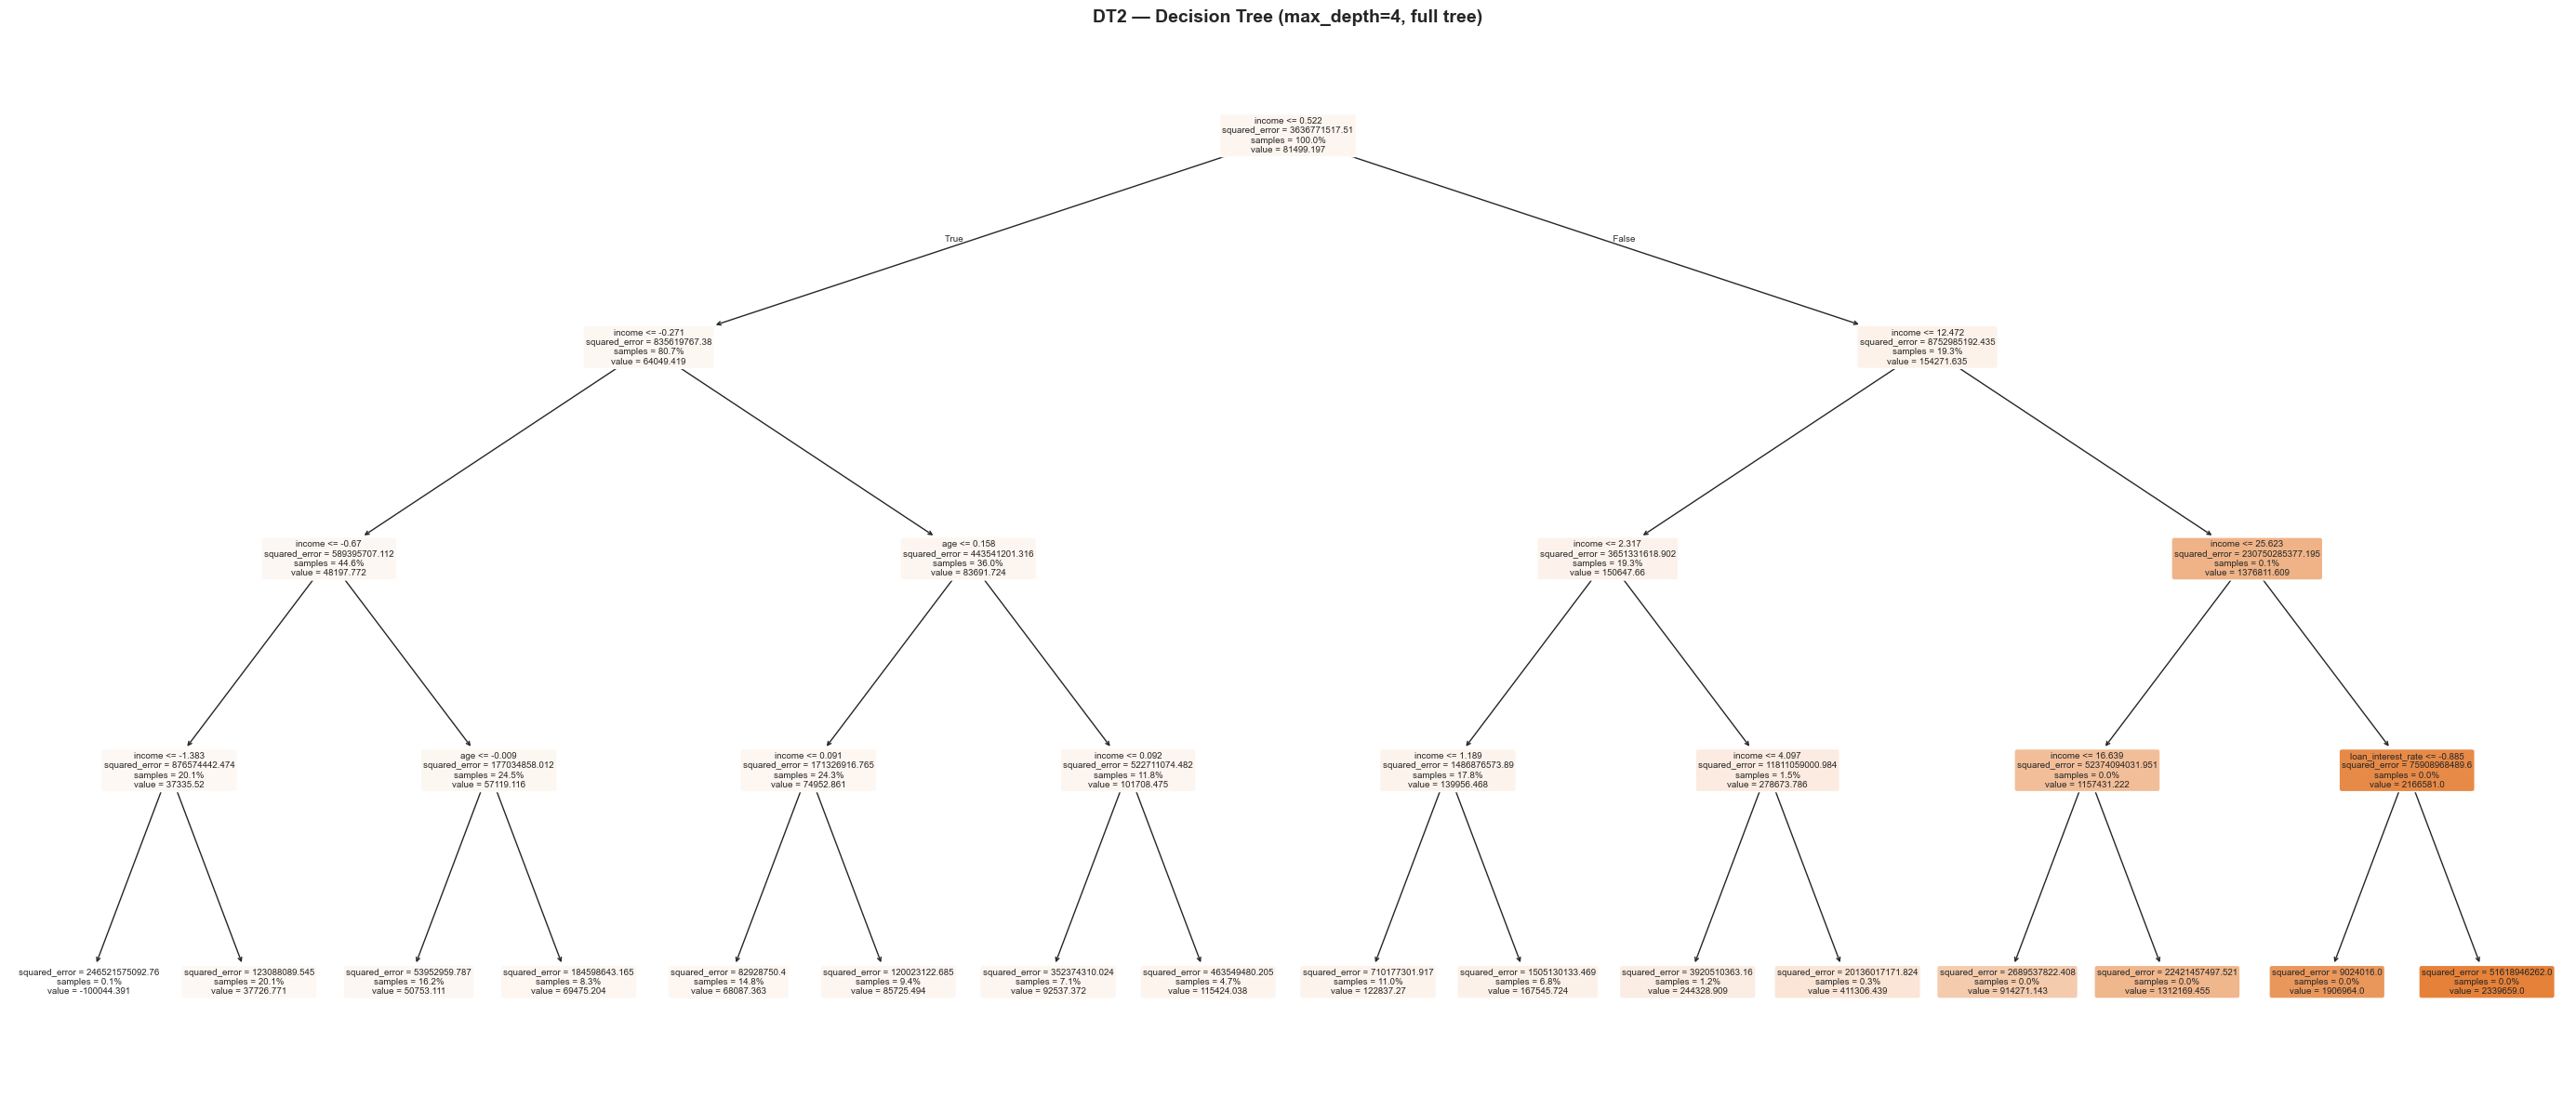

In [19]:
# Create a figure for DT2 visualisation
plt.figure(figsize=(28, 12))

# Plot DT2 in full (max_depth=4)
plot_tree(
    dt2_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=7
)

# Set the title for DT2
plt.title('DT2 — Decision Tree (max_depth=4, full tree)', fontsize=14, fontweight='bold')

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the plot
plt.show()

### Step 18 — Verify Regression Target Distribution

We check the unique values in the regression target to ensure the trees are learning meaningful splits.  
If the target has only one unique value, the tree will have no meaningful splits.

In [20]:
# Print the number of unique values in the regression target
print(f'Number of unique values in y_regression: {y_regression.nunique()}')

# Print a sample of unique values (first 20)
print(f'\nSample unique values (first 20): {sorted(y_regression.unique())[:20]}')

# Check if target has sufficient variation for meaningful splits
if y_regression.nunique() <= 1:
    # Explain the issue if only one value exists
    print('\n⚠️ WARNING: y_regression has only one unique value.')
    print('The decision tree cannot make meaningful splits with constant target values.')
else:
    # Confirm sufficient variation exists
    print(f'\n✓ Target variable has {y_regression.nunique()} unique values — sufficient for meaningful tree splits.')

Number of unique values in y_regression: 22587

Sample unique values (first 20): [np.int64(-2426900), np.int64(-111739), np.int64(-89000), np.int64(232), np.int64(1000), np.int64(1200), np.int64(1207), np.int64(1500), np.int64(1800), np.int64(2000), np.int64(2400), np.int64(2450), np.int64(2500), np.int64(2800), np.int64(3000), np.int64(3100), np.int64(3250), np.int64(3275), np.int64(3500), np.int64(3600)]

✓ Target variable has 22587 unique values — sufficient for meaningful tree splits.


---
## Part C — Client Prediction

We create a new client sample by modifying an existing row from the regression dataset, then use both Decision Tree models to predict the `max_allowed_loan` for this client.

### Step 19 — Create New Client Sample

We copy the first row from `X_regression_scaled` and modify some values to simulate a new client application.

In [21]:
# Copy the first row from X_regression_scaled as a base for the new client
new_client = X_regression_scaled.iloc[[0]].copy()

# Get the list of column names for reference
col_names = list(new_client.columns)

# Print original values for reference
print('=== Original Sample Values ===')

# Display the original values
print(new_client.to_string(index=False))

# Modify specific feature values to simulate a different client profile
# Increase the first feature value (e.g., age-related) by 0.5 standard deviations
new_client.iloc[0, 0] = new_client.iloc[0, 0] + 0.5

# Increase the second feature value (e.g., income-related) by 1.0 standard deviations
new_client.iloc[0, 1] = new_client.iloc[0, 1] + 1.0

# Decrease the third feature value (e.g., loan-related) by 0.3 standard deviations
new_client.iloc[0, 2] = new_client.iloc[0, 2] - 0.3

# Print confirmation of modifications
print('\n=== Modified Client Sample ===')

# Print which columns were modified
print(f'Modified columns: {col_names[0]}, {col_names[1]}, {col_names[2]}')

=== Original Sample Values ===
      age    income  home_ownership  emplyment_length  loan_intent  loan_amount  loan_interest_rate  loan_income_ratio  payment_default_on_file  credit_history_length
-1.095989 -1.390672        0.313524         -1.216172    -0.897806     1.146915           -1.155562          -0.322411                -0.371482              -0.454416

=== Modified Client Sample ===
Modified columns: age, income, home_ownership


### Step 20 — Display New Client Sample

We display the full feature values of the new client sample.

In [22]:
# Print a header for the new client sample
print('=== New Client Feature Values ===')

# Display the new client sample as a transposed DataFrame for readability
print(new_client.T.to_string(header=False))

=== New Client Feature Values ===
age                     -0.595989
income                  -0.390672
home_ownership           0.013524
emplyment_length        -1.216172
loan_intent             -0.897806
loan_amount              1.146915
loan_interest_rate      -1.155562
loan_income_ratio       -0.322411
payment_default_on_file -0.371482
credit_history_length   -0.454416


### Step 21 — Predict Max Allowed Loan for New Client

We use both DT1 and DT2 to predict the `max_allowed_loan` for the new client.

In [23]:
# Predict using DT1 (default depth)
pred_dt1 = dt1_model.predict(new_client)

# Predict using DT2 (max_depth=4)
pred_dt2 = dt2_model.predict(new_client)

# Print the predictions header
print('=== Client Prediction Results ===')

# Print DT1 prediction
print(f'DT1 (Default) predicted max_allowed_loan:     {pred_dt1[0]:,.2f}')

# Print DT2 prediction
print(f'DT2 (max_depth=4) predicted max_allowed_loan: {pred_dt2[0]:,.2f}')

=== Client Prediction Results ===
DT1 (Default) predicted max_allowed_loan:     52,376.00
DT2 (max_depth=4) predicted max_allowed_loan: 50,753.11


### Step 22 — Prediction Results with Explanation

We present the final prediction results with clear formatting and an explanation of the differences.

In [24]:
# Print a formatted summary of predictions
print('=' * 60)
print('CLIENT PREDICTION — RESULTS')
print('=' * 60)

# Print DT1 prediction result
print(f'\n  DT1 (Default) Prediction:     £{pred_dt1[0]:,.2f}')

# Print DT2 prediction result
print(f'  DT2 (max_depth=4) Prediction: £{pred_dt2[0]:,.2f}')

# Calculate the difference between predictions
diff = abs(pred_dt1[0] - pred_dt2[0])

# Print the difference
print(f'\n  Difference: £{diff:,.2f}')

# Print an explanation
print('\n  Explanation:')
print('  DT1 (default) has no depth restriction and may overfit the training data,')
print('  which can lead to more extreme predictions. DT2 (max_depth=4) is more')
print('  constrained and typically generalises better to unseen data.')

# Print closing separator
print('=' * 60)

CLIENT PREDICTION — RESULTS

  DT1 (Default) Prediction:     £52,376.00
  DT2 (max_depth=4) Prediction: £50,753.11

  Difference: £1,622.89

  Explanation:
  DT1 (default) has no depth restriction and may overfit the training data,
  which can lead to more extreme predictions. DT2 (max_depth=4) is more
  constrained and typically generalises better to unseen data.


---
## Final Summary

We print a consolidated summary of all results from this notebook.

In [25]:
# Print the final summary banner
print('\n' + '=' * 60)
print('NOTEBOOK 3 — FINAL SUMMARY')
print('=' * 60)

# Print the ensemble classification results header
print('\n=== PART A: Ensemble Classification ===')

# Print model type
print(f'Model:                   Voting Classifier (LR + KNN, soft voting)')

# Print accuracy
print(f'Accuracy:                {acc_ensemble:.4f}')

# Print recall for the reject class
print(f'Recall (Reject class):   {rec_ensemble:.4f}')

# Print precision
print(f'Precision:               {prec_ensemble:.4f}')

# Print F1-score
print(f'F1-Score:                {f1_ensemble:.4f}')

# Print AUC-ROC
print(f'AUC-ROC:                 {auc_ensemble:.4f}')

# Print the regression results header
print('\n=== PART B: Decision Tree Regression ===')

# Print DT1 results
print(f'DT1 (Default):    MSE={mse_dt1:,.2f}  MAE={mae_dt1:,.2f}  R²={r2_dt1:.4f}')

# Print DT2 results
print(f'DT2 (depth=4):    MSE={mse_dt2:,.2f}  MAE={mae_dt2:,.2f}  R²={r2_dt2:.4f}')

# Determine the best regression model based on R²
if r2_dt1 > r2_dt2:
    # DT1 has higher R²
    best_reg = 'DT1 (Default)'
else:
    # DT2 has higher R² (or they are equal)
    best_reg = 'DT2 (max_depth=4)'

# Print the best model decision
print(f'\n=== Best Regression Model ===')

# Print which model performed best
print(f'Based on R² score, the best model is: {best_reg}')

# Print the client prediction summary
print('\n=== PART C: Client Prediction ===')

# Print DT1 prediction
print(f'DT1 Prediction: £{pred_dt1[0]:,.2f}')

# Print DT2 prediction
print(f'DT2 Prediction: £{pred_dt2[0]:,.2f}')

# Print the closing banner
print('\n' + '=' * 60)
print('All tasks in Notebook 3 completed successfully.')
print('=' * 60)


NOTEBOOK 3 — FINAL SUMMARY

=== PART A: Ensemble Classification ===
Model:                   Voting Classifier (LR + KNN, soft voting)
Accuracy:                0.9939
Recall (Reject class):   0.9790
Precision:               0.9785
F1-Score:                0.9787
AUC-ROC:                 0.9996

=== PART B: Decision Tree Regression ===
DT1 (Default):    MSE=69,738,517.91  MAE=1,244.92  R²=0.9765
DT2 (depth=4):    MSE=404,642,149.18  MAE=11,935.26  R²=0.8639

=== Best Regression Model ===
Based on R² score, the best model is: DT1 (Default)

=== PART C: Client Prediction ===
DT1 Prediction: £52,376.00
DT2 Prediction: £50,753.11

All tasks in Notebook 3 completed successfully.
